In [2]:
from datasets import load_dataset
import pandas as pd
ds = load_dataset("surrey-nlp/BESSTIE-CW-26")
df = pd.DataFrame(ds['train'])
print(df.head())
print(df.columns)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/711k [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/70.6k [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/415k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/3747 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/313 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2183 [00:00<?, ? examples/s]

                                                text variety  source  \
0  I'm a member of the Green Party but I'll be vo...   en-UK  Reddit   
1  Yeah it blew out to 3x what it was budgeted fo...   en-AU  Reddit   
2  Food was pretty great. A little dry, but I am ...   en-AU  Google   
3  Firstly the staff seemed as if they did n't wa...   en-UK  Google   
4  We came for lunch and enjoyed the food we orde...   en-UK  Google   

   Sentiment  Sarcasm  
0        0.0      0.0  
1        0.0      1.0  
2        1.0      0.0  
3        0.0      0.0  
4        1.0      0.0  
Index(['text', 'variety', 'source', 'Sentiment', 'Sarcasm'], dtype='object')


In [3]:
print(df.isnull().sum())
df = df[['text', 'variety', 'source', 'Sentiment', 'Sarcasm']]
print(df['variety'].unique())

text         0
variety      0
source       0
Sentiment    0
Sarcasm      0
dtype: int64
['en-UK' 'en-AU' 'en-IN']


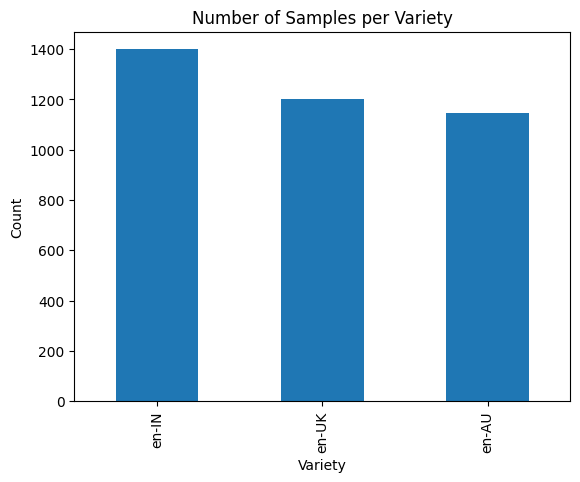

In [4]:
import matplotlib.pyplot as plt
variety_counts = df['variety'].value_counts()
plt.figure()
variety_counts.plot(kind='bar')
plt.title("Number of Samples per Variety")
plt.xlabel("Variety")
plt.ylabel("Count")
plt.show()

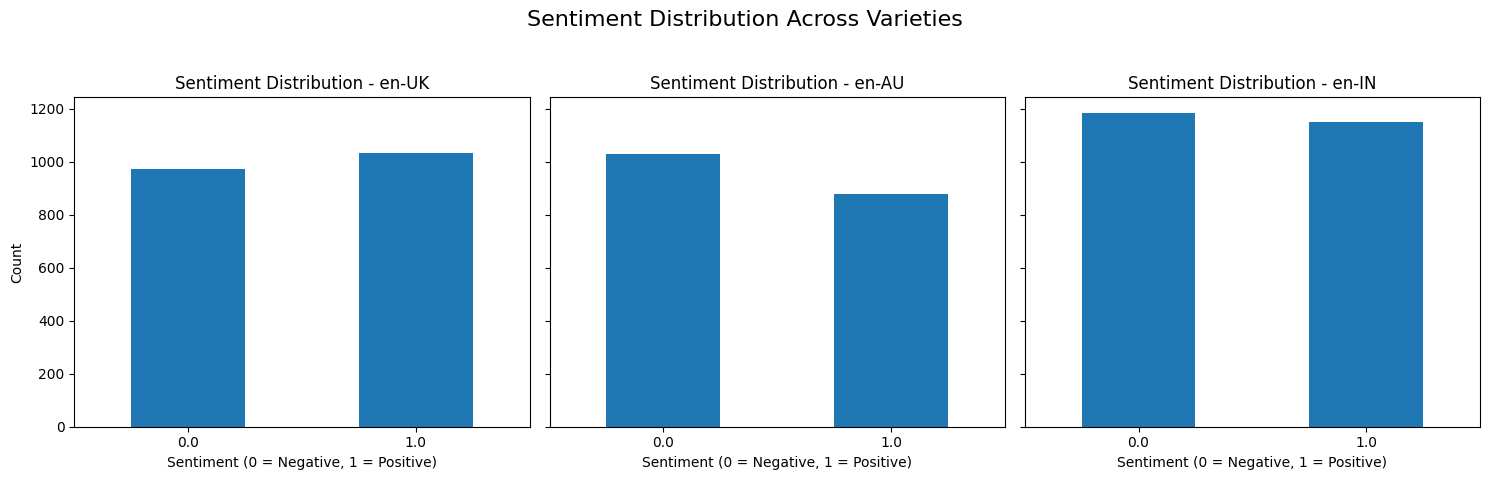

In [33]:
import matplotlib.pyplot as plt

varieties = df['variety'].unique()


fig, axes = plt.subplots(1, len(varieties), figsize=(15, 5), sharey=True)

if len(varieties) == 1:
    axes = [axes]

for i, v in enumerate(varieties):
    subset = df[df['variety'] == v]
    counts = subset['Sentiment'].value_counts().sort_index()
    counts.plot(kind='bar', ax=axes[i])
    axes[i].set_title(f"Sentiment Distribution - {v}")
    axes[i].set_xlabel("Sentiment (0 = Negative, 1 = Positive)")
    axes[i].tick_params(axis='x', rotation=0)

axes[0].set_ylabel("Count")

plt.suptitle("Sentiment Distribution Across Varieties", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

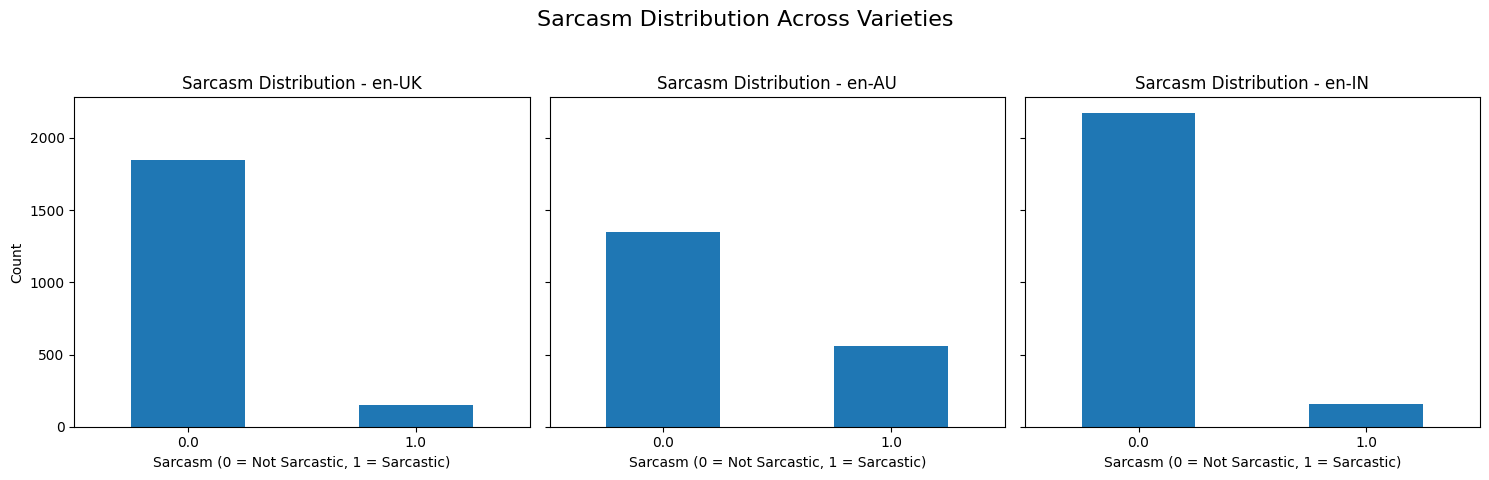

In [34]:
import matplotlib.pyplot as plt

varieties = df['variety'].unique()

fig, axes = plt.subplots(1, len(varieties), figsize=(15, 5), sharey=True)

if len(varieties) == 1:
    axes = [axes]

for i, v in enumerate(varieties):
    subset = df[df['variety'] == v]
    counts = subset['Sarcasm'].value_counts().sort_index()
    counts.plot(kind='bar', ax=axes[i])
    axes[i].set_title(f"Sarcasm Distribution - {v}")
    axes[i].set_xlabel("Sarcasm (0 = Not Sarcastic, 1 = Sarcastic)")
    axes[i].tick_params(axis='x', rotation=0)

axes[0].set_ylabel("Count")

plt.suptitle("Sarcasm Distribution Across Varieties", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

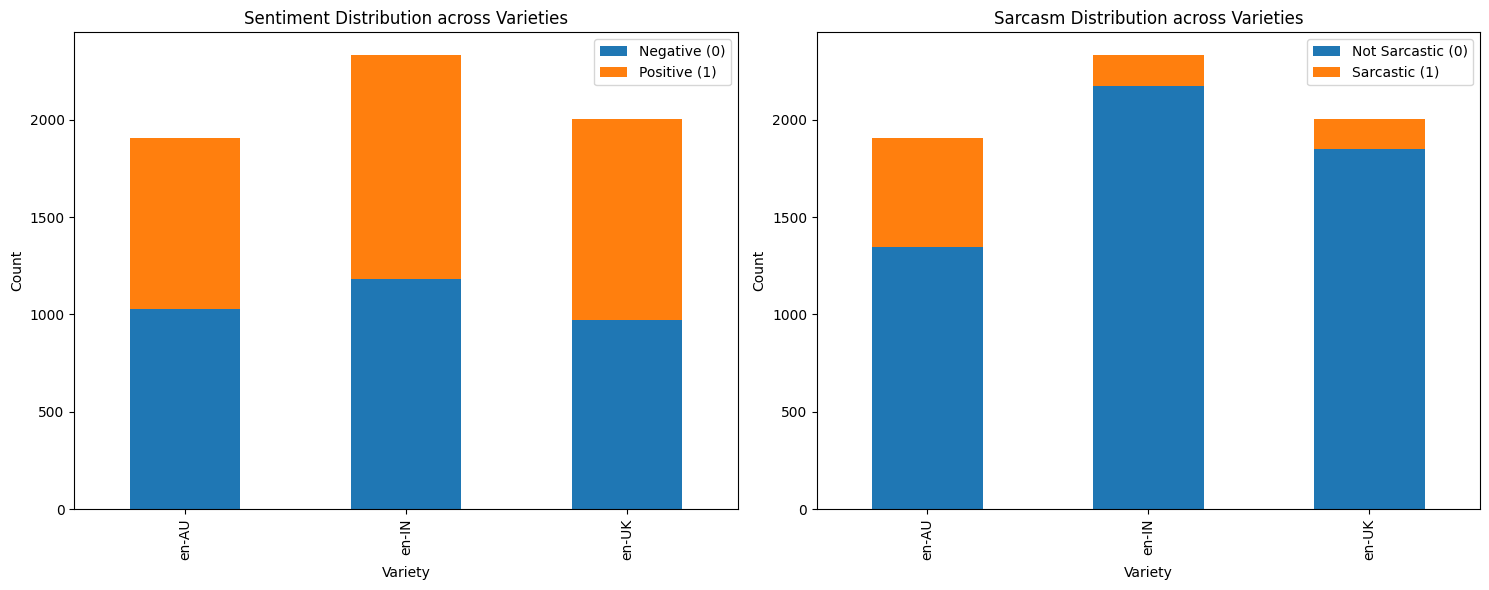

In [35]:
import matplotlib.pyplot as plt

sentiment_table = pd.crosstab(df['variety'], df['Sentiment'])
sarcasm_table = pd.crosstab(df['variety'], df['Sarcasm'])

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sentiment_table.plot(kind='bar', stacked=True, ax=axes[0])
axes[0].set_title("Sentiment Distribution across Varieties")
axes[0].set_xlabel("Variety")
axes[0].set_ylabel("Count")
axes[0].legend(["Negative (0)", "Positive (1)"])

sarcasm_table.plot(kind='bar', stacked=True, ax=axes[1])
axes[1].set_title("Sarcasm Distribution across Varieties")
axes[1].set_xlabel("Variety")
axes[1].set_ylabel("Count")
axes[1].legend(["Not Sarcastic (0)", "Sarcastic (1)"])

plt.tight_layout()
plt.show()

In [8]:
sentiment_percent = sentiment_table.div(sentiment_table.sum(axis=1), axis=0)
sarcasm_percent = sarcasm_table.div(sarcasm_table.sum(axis=1), axis=0)
print("Sentiment %:\n", sentiment_percent)
print("\nSarcasm %:\n", sarcasm_percent)

Sentiment %:
 Sentiment       0.0       1.0
variety                      
en-AU      0.552838  0.447162
en-IN      0.492495  0.507505
en-UK      0.486284  0.513716

Sarcasm %:
 Sarcasm       0.0       1.0
variety                    
en-AU    0.705677  0.294323
en-IN    0.932094  0.067906
en-UK    0.923525  0.076475


In [9]:
#!pip install spacy
#!python -m spacy download en_core_web_sm
import spacy
nlp = spacy.load("en_core_web_sm")

In [22]:
from collections import Counter

def get_pos_counts(texts, limit=500):
    pos_counter = Counter()

    for text in texts[:limit]:
        doc = nlp(text)
        for token in doc:
            pos_counter[token.pos_] += 1

    return pos_counter


sarcastic_texts = df[df['Sarcasm'] == 1]['text'].tolist()
normal_texts = df[df['Sarcasm'] == 0]['text'].tolist()
sarcastic_pos = get_pos_counts(sarcastic_texts)
normal_pos = get_pos_counts(normal_texts)

print("Sarcastic POS (Counts):")
print(sarcastic_pos.most_common(10))
print("\nNon-Sarcastic POS (Counts):")
print(normal_pos.most_common(10))
print("\nSarcastic POS (Percentages):")
total_sarcastic_pos = sum(sarcastic_pos.values())
for pos, count in sarcastic_pos.most_common(10):
    print(f"{pos}: {(count / total_sarcastic_pos * 100):.2f}%")

print("\nNon-Sarcastic POS (Percentages):")
total_normal_pos = sum(normal_pos.values())
for pos, count in normal_pos.most_common(10):
    print(f"{pos}: {(count / total_normal_pos * 100):.2f}%")

Sarcastic POS (Counts):
[('NOUN', 3944), ('VERB', 2636), ('PUNCT', 2282), ('PRON', 2114), ('ADP', 1930), ('DET', 1767), ('AUX', 1657), ('ADJ', 1564), ('ADV', 1187), ('PROPN', 1057)]

Non-Sarcastic POS (Counts):
[('NOUN', 5393), ('PUNCT', 3066), ('VERB', 2919), ('ADJ', 2754), ('ADP', 2437), ('PRON', 2397), ('DET', 2369), ('AUX', 2110), ('ADV', 1813), ('CCONJ', 1151)]

Sarcastic POS (Percentages):
NOUN: 17.12%
VERB: 11.44%
PUNCT: 9.90%
PRON: 9.18%
ADP: 8.38%
DET: 7.67%
AUX: 7.19%
ADJ: 6.79%
ADV: 5.15%
PROPN: 4.59%

Non-Sarcastic POS (Percentages):
NOUN: 18.40%
PUNCT: 10.46%
VERB: 9.96%
ADJ: 9.40%
ADP: 8.32%
PRON: 8.18%
DET: 8.08%
AUX: 7.20%
ADV: 6.19%
CCONJ: 3.93%


In [11]:
def extract_dependencies(texts, limit=50):
    for text in texts[:limit]:
        doc = nlp(text)
        print("\nTEXT:", text)
        for token in doc:
            print(token.text, "->", token.dep_, "->", token.head.text)

extract_dependencies(sarcastic_texts)


TEXT: Yeah it blew out to 3x what it was budgeted for. Who wouldve thought giving people free cash to reovate their house would dry up resources for new builds...
Yeah -> intj -> blew
it -> nsubj -> blew
blew -> ROOT -> blew
out -> prt -> blew
to -> prep -> blew
3x -> pobj -> to
what -> pobj -> for
it -> nsubjpass -> budgeted
was -> auxpass -> budgeted
budgeted -> ccomp -> blew
for -> prep -> budgeted
. -> punct -> blew
Who -> nsubj -> thought
would -> aux -> thought
ve -> aux -> thought
thought -> ROOT -> thought
giving -> csubj -> dry
people -> dative -> giving
free -> amod -> cash
cash -> dobj -> giving
to -> aux -> reovate
reovate -> advcl -> giving
their -> poss -> house
house -> dobj -> reovate
would -> aux -> dry
dry -> ccomp -> thought
up -> prt -> dry
resources -> dobj -> dry
for -> prep -> resources
new -> amod -> builds
builds -> pobj -> for
... -> punct -> thought

TEXT: Cheerful fellow aren't you.
Cheerful -> amod -> fellow
fellow -> nsubj -> are
are -> ROOT -> are
n't ->

In [14]:
from collections import Counter
import re

def get_top_words(texts, limit=500):
    words = []

    for text in texts[:limit]:
        words.extend(re.findall(r'\b\w+\b', text.lower()))

    return Counter(words).most_common(200)


print("Top words in en-IN:")
print(get_top_words(ind_texts))

Top words in en-IN:
[('the', 770), ('and', 561), ('is', 450), ('a', 374), ('to', 364), ('of', 304), ('in', 240), ('good', 240), ('for', 237), ('it', 234), ('i', 228), ('was', 212), ('this', 166), ('with', 157), ('but', 152), ('you', 142), ('food', 140), ('are', 139), ('they', 130), ('that', 126), ('not', 122), ('very', 110), ('place', 109), ('have', 102), ('t', 97), ('s', 94), ('on', 93), ('so', 90), ('also', 81), ('as', 80), ('be', 79), ('there', 79), ('at', 77), ('one', 73), ('we', 71), ('all', 69), ('can', 67), ('my', 61), ('or', 61), ('their', 61), ('like', 60), ('service', 60), ('here', 58), ('from', 56), ('taste', 55), ('chicken', 55), ('nice', 52), ('were', 52), ('if', 49), ('too', 48), ('has', 47), ('only', 44), ('staff', 44), ('great', 42), ('just', 42), ('n', 42), ('about', 41), ('people', 41), ('will', 40), ('best', 39), ('he', 39), ('by', 39), ('restaurant', 39), ('no', 38), ('other', 38), ('an', 38), ('get', 38), ('do', 38), ('which', 37), ('quality', 36), ('your', 36), ('

In [15]:
import re

def count_punctuation(texts, symbol):
    count = 0
    for text in texts:
        count += len(re.findall(re.escape(symbol), text))
    return count


symbols = ['!', '?', '...']

for s in symbols:
    print(f"{s} in sarcastic:", count_punctuation(sarcastic_texts, s))
    print((df['Sarcasm'].value_counts(normalize=True) * 100).round(2))
    print(f"{s} in non-sarcastic:", count_punctuation(normal_texts, s))
    print((df['Sarcasm'].value_counts(normalize=True) * 100).round(2))

Overall Sarcasm Distribution (%):
Sarcasm
0.0    86.02
1.0    13.98
Name: proportion, dtype: float64

Punctuation Percentages:
'!' in overall dataset: 18.82%
'!' in sarcastic texts: 8.78%
'!' in non-sarcastic texts: 20.45%

'?' in overall dataset: 14.22%
'?' in sarcastic texts: 29.96%
'?' in non-sarcastic texts: 11.67%

'...' in overall dataset: 11.58%
'...' in sarcastic texts: 8.97%
'...' in non-sarcastic texts: 12.01%



In [16]:
def count_uppercase(texts, limit=500):
    count = 0

    for text in texts[:limit]:
        for word in text.split():
            if word.isupper() and len(word) > 2:
                count += 1

    return count


print("Uppercase (sarcastic):", count_uppercase(sarcastic_texts))
print("Uppercase (normal):", count_uppercase(normal_texts))

Uppercase (sarcastic): 123
Uppercase (normal): 59


In [17]:
def get_vocab(texts, limit=1000):
    vocab = set()

    for text in texts[:limit]:
        words = text.lower().split()
        vocab.update(words)

    return vocab


uk_vocab = get_vocab(df[df['variety']=='en-UK']['text'])
au_vocab = get_vocab(df[df['variety']=='en-AU']['text'])
in_vocab = get_vocab(df[df['variety']=='en-IN']['text'])


print("Words only in en-IN:", list(in_vocab - uk_vocab - au_vocab)[:20])
print("Words only in en-AU:", list(au_vocab - in_vocab - uk_vocab)[:20])
print("Words only in en-UK:", list(uk_vocab - in_vocab - au_vocab)[:20])

Words only in en-IN: ['gag', 'asthmatics', 'shares.', 'everywhere!', 'route.', 'toll', 'arguing', 'sikkim', 'aqi', 'partitioned', 'junagadh', 'mini-bar', 'delusion', 'ambani', 'together"', 'effect.', 'gone,', 'kamse', 'backyard', 'macha']
Words only in en-AU: ['border.', 'amazing)', 'scratching', 'cheerful-looking', 'emptied,', 'scare', 'jim', 'indexed', 'acknowledgement', 'hume', '"we', 'tropical', '/r/melbourne', 'slogans', 'medications', 'barriers', 'somthin', 'youll', 'mascoma', 'compromised']
Words only in en-UK: ['keble.', 'wildwood', 'preface', 'pig', 'worship.', 'disconcerting', 'angle,', 'blackberry', 'delivers,', 'over..', 'companions.', 'hammersmith', 'though!', 'memory,', 'mains,', 'ticks', "club'", 'destroyed', 'r/unitedkingdom', 'warm-which']


In [18]:
from collections import Counter

def get_bigrams(texts, limit=500):
    bigrams = []

    for text in texts[:limit]:
        words = text.lower().split()
        for i in range(len(words)-1):
            bigrams.append((words[i], words[i+1]))

    return Counter(bigrams).most_common(10)


print("Sarcastic bigrams:", get_bigrams(sarcastic_texts))
print("Non-sarcastic bigrams:", get_bigrams(normal_texts))

Sarcastic bigrams: [(('in', 'the'), 63), (('of', 'the'), 56), (('to', 'the'), 48), (('and', 'the'), 37), (('for', 'the'), 35), (('this', 'is'), 28), (('with', 'the'), 28), (('to', 'be'), 27), (('is', 'a'), 27), (('it', 'is'), 21)]
Non-sarcastic bigrams: [(('of', 'the'), 94), (('in', 'the'), 76), (('it', 'was'), 69), (('and', 'the'), 68), (('on', 'the'), 60), (('to', 'be'), 49), (('for', 'a'), 48), (('is', 'a'), 42), (('it', 'is'), 42), (('for', 'the'), 41)]


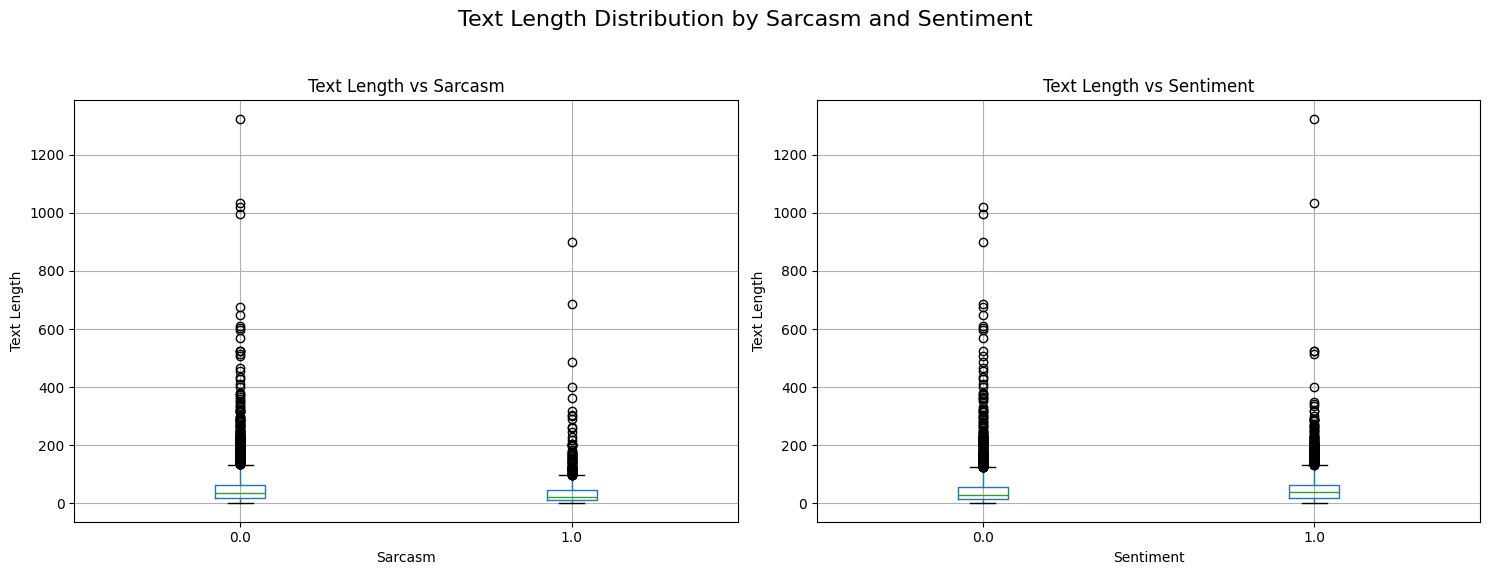

In [38]:
import matplotlib.pyplot as plt

df["length"] = df["text"].apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

df.boxplot(column="length", by="Sarcasm", ax=axes[0])
axes[0].set_title("Text Length vs Sarcasm")
axes[0].set_xlabel("Sarcasm")
axes[0].set_ylabel("Text Length")

df.boxplot(column="length", by="Sentiment", ax=axes[1])
axes[1].set_title("Text Length vs Sentiment")
axes[1].set_xlabel("Sentiment")
axes[1].set_ylabel("Text Length")

plt.suptitle("Text Length Distribution by Sarcasm and Sentiment", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

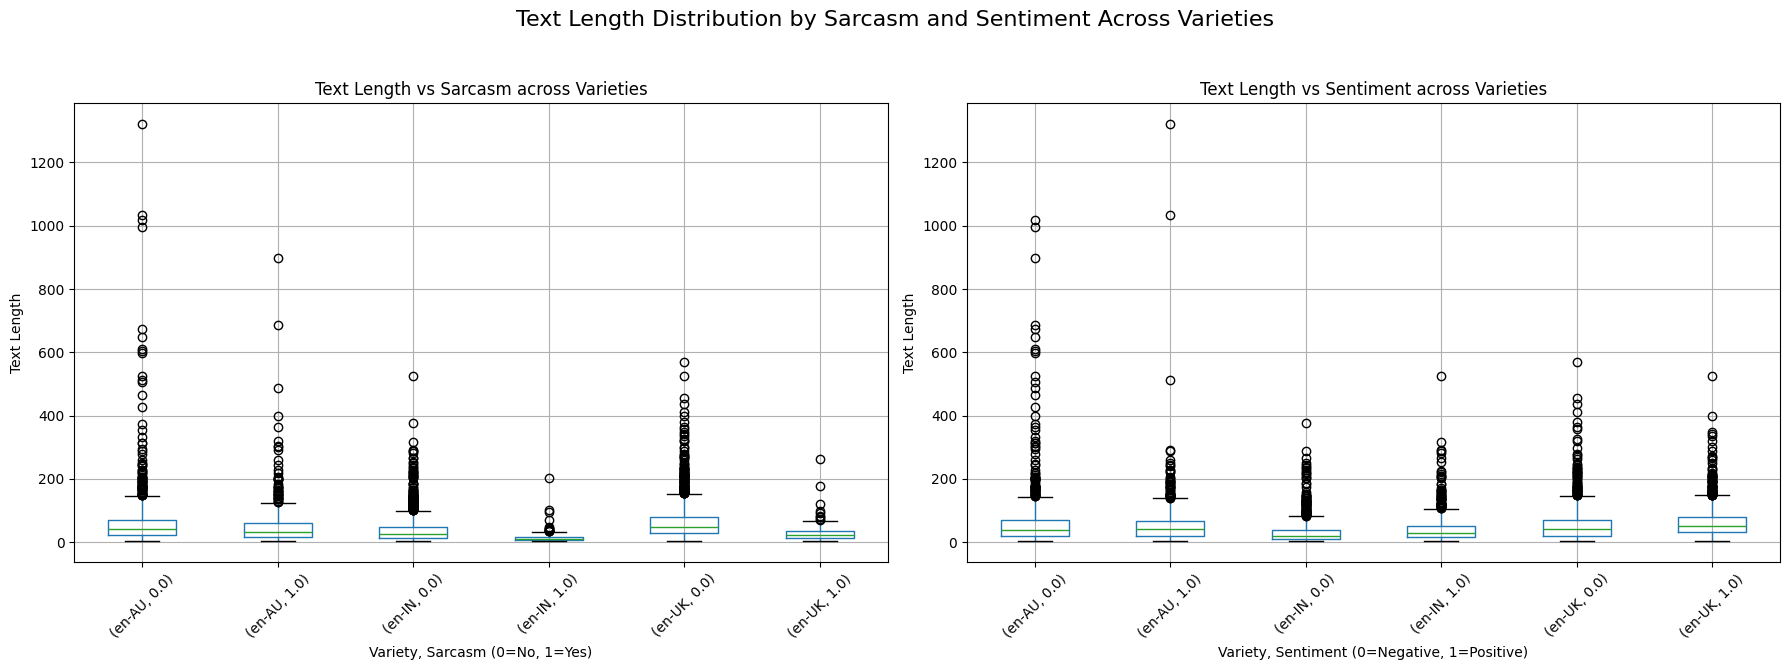

In [39]:
import matplotlib.pyplot as plt

df["length"] = df["text"].apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Plot 1
df.boxplot(column="length", by=["variety", "Sarcasm"], ax=axes[0])
axes[0].set_title("Text Length vs Sarcasm across Varieties")
axes[0].set_xlabel("Variety, Sarcasm (0=No, 1=Yes)")
axes[0].set_ylabel("Text Length")
axes[0].tick_params(axis='x', rotation=45)

# Plot 2
df.boxplot(column="length", by=["variety", "Sentiment"], ax=axes[1])
axes[1].set_title("Text Length vs Sentiment across Varieties")
axes[1].set_xlabel("Variety, Sentiment (0=Negative, 1=Positive)")
axes[1].set_ylabel("Text Length")
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle("Text Length Distribution by Sarcasm and Sentiment Across Varieties", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [28]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()

df['cleaned_text'] = df['text'].apply(clean_text)

print("Original text sample:", df['text'].iloc[0])
print("Cleaned text sample:", df['cleaned_text'].iloc[0])
print("DataFrame head with cleaned text:")
print(df[['text', 'cleaned_text']].head())

Original text sample: I'm a member of the Green Party but I'll be voting Lib Dem as it's so tight here between Lib Dem and Tory. I cannot contemplate our useless tit of a Tory MP being reelected. I'll use the Swap My Vote website so someone somewhere can vote Green for me.
Cleaned text sample: im a member of the green party but ill be voting lib dem as its so tight here between lib dem and tory i cannot contemplate our useless tit of a tory mp being reelected ill use the swap my vote website so someone somewhere can vote green for me
DataFrame head with cleaned text:
                                                text  \
0  I'm a member of the Green Party but I'll be vo...   
1  Yeah it blew out to 3x what it was budgeted fo...   
2  Food was pretty great. A little dry, but I am ...   
3  Firstly the staff seemed as if they did n't wa...   
4  We came for lunch and enjoyed the food we orde...   

                                        cleaned_text  
0  im a member of the green party 

In [32]:
!pip install wordfreq
from wordfreq import zipf_frequency

def is_english_word(word):
    return zipf_frequency(word, 'en') > 0

def has_non_english(text):
    words = text.lower().split()
    for w in words:
        if not is_english_word(w):
            return 1
    return 0

df["non_english"] = df["text"].apply(has_non_english)
print(df["non_english"].value_counts(normalize=True))
print(df.groupby("Sarcasm")["non_english"].mean())
print(df.groupby("Sentiment")["non_english"].mean())
print(df.groupby("variety")["non_english"].mean())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.8/56.8 MB 18.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.1/183.1 kB 11.1 MB/s eta 0:00:00
non_english
0    0.718885
1    0.281115
Name: proportion, dtype: float64
Sarcasm
0.0    0.281564
1.0    0.278351
Name: non_english, dtype: float64
Sentiment
0.0    0.281093
1.0    0.281138
Name: non_english, dtype: float64
variety
en-AU    0.261668
en-IN    0.338765
en-UK    0.232535
Name: non_english, dtype: float64
